In [111]:
import pandas as pd
import numpy as np

In [112]:
#importing the dataset
flux_dataset=pd.read_csv("../D2/Astro_Flux_Data.csv")
time_stamp_dataset=pd.read_csv("../D2/Astro_Time_Data.csv")

print("flux dataset columns: ", flux_dataset.columns)
print("time dataset columns: ", time_stamp_dataset.columns)

print("Number of null fields in FLUX dataset: ", flux_dataset.isna().sum())
print("Number of null fields in Time dataset: ", time_stamp_dataset.isna().sum())


flux dataset columns:  Index(['Unnamed: 0', 'id', 'class', 'flux_1', 'flux_2', 'flux_3', 'flux_4',
       'flux_5', 'flux_6', 'flux_7',
       ...
       'flux_4601', 'flux_4602', 'flux_4603', 'flux_4604', 'flux_4605',
       'flux_4606', 'flux_4607', 'flux_4608', 'flux_4609', 'flux_4610'],
      dtype='object', length=4613)
time dataset columns:  Index(['Unnamed: 0', 'id', 'class', 'time_1', 'time_2', 'time_3', 'time_4',
       'time_5', 'time_6', 'time_7',
       ...
       'time_4599', 'time_4600', 'time_4601', 'time_4602', 'time_4603',
       'time_4604', 'time_4605', 'time_4606', 'time_4607', 'time_4608'],
      dtype='object', length=4611)
Number of null fields in FLUX dataset:  Unnamed: 0       0
id               0
class            0
flux_1           0
flux_2           0
              ... 
flux_4606      333
flux_4607     1420
flux_4608     3761
flux_4609        0
flux_4610        0
Length: 4613, dtype: int64
Number of null fields in Time dataset:  Unnamed: 0       0
id         

N/A values have been identified => Null value handling in preprocessing phase

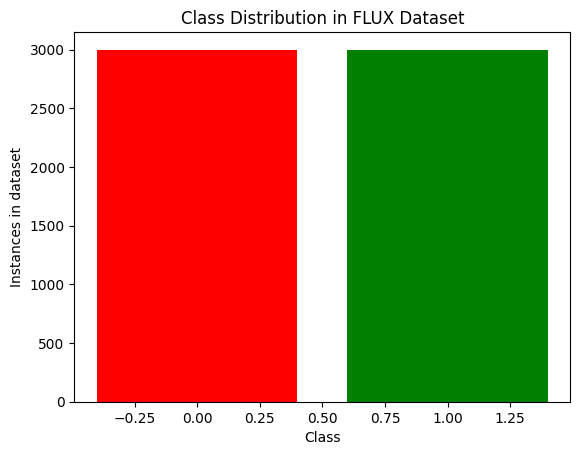

In [113]:
#checking distribution of classes (no-exoplanet(0) and exoplanet(1))

import matplotlib.pyplot as plt
class_counts=flux_dataset.value_counts('class')
classes=dict(class_counts)
plt.bar(classes.keys(), height=classes.values(), color=['red', 'green'])
plt.title("Class Distribution in FLUX Dataset")
plt.xlabel("Class")
plt.ylabel("Instances in dataset")
plt.show()


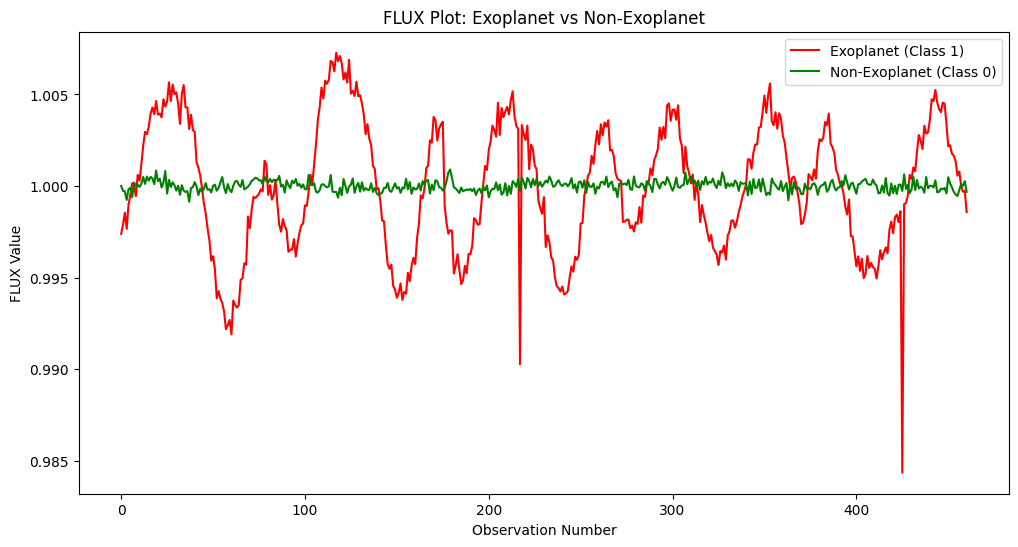

In [136]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Selecting a sample flux data for exoplanet (class 1) and non-exoplanet (class 0)
plot1 = flux_dataset[flux_dataset['class'] == 1].iloc[0, 3:].values  # Ensure full flux data
plot2 = flux_dataset[flux_dataset['class'] == 0].iloc[0, 3:].values

# Downsample for better visualization
plot1_reduced = plot1[::10]  # Take every 10th point
plot2_reduced = plot2[::10]

# Plot flux data
plt.figure(figsize=(12, 6))
plt.plot(range(len(plot1_reduced)), plot1_reduced, color='red', label='Exoplanet (Class 1)')
plt.plot(range(len(plot2_reduced)), plot2_reduced, color='green', label='Non-Exoplanet (Class 0)')

plt.title("FLUX Plot: Exoplanet vs Non-Exoplanet")
plt.xlabel("Observation Number")
plt.ylabel("FLUX Value")
plt.legend()
plt.show()



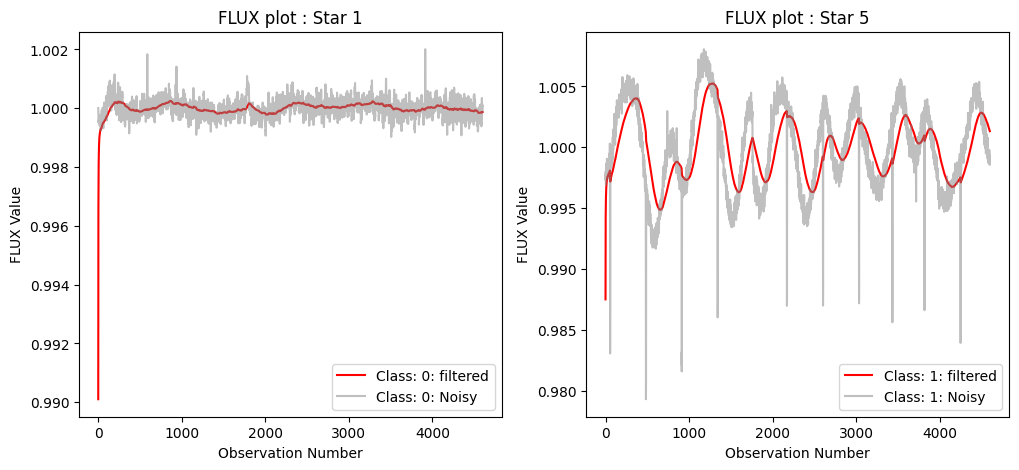

In [159]:
#applying Savitzky-Golay filter to remove noise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

from pykalman import KalmanFilter



kf = KalmanFilter(initial_state_mean=0, 
                  n_dim_obs=1, 
                  transition_matrices=[1], 
                  observation_matrices=[1], 
                  transition_covariance=[1e-6], 
                  observation_covariance=[1e-2])


filtered1, _ = kf.filter(flux_dataset.iloc[0, 3:].values)
label1="Class: "+str(flux_dataset.iloc[0,2])# class 0(No Exoplanet)
filtered2, _ = kf.filter(flux_dataset.iloc[5, 3:].values)
label2="Class: "+str(flux_dataset.iloc[5,2])#  class 1(Exoplanet)
# Plot the results

fig, axes = plt.subplots(1, 2, figsize=(12, 5)) 

axes[0].plot(range(len(filtered1[0:4600])), filtered1[0:4600], color='red', label=label1+": filtered")
axes[0].plot(range(len(flux_dataset.iloc[0, 3:4603].values)), flux_dataset.iloc[0, 3:4603].values, alpha=0.5, color='grey', label=label1+": Noisy")

axes[1].plot(range(len(filtered2[0:4600])), filtered2[0:4600], color='red', label=label2+": filtered")  # Fixed `label1` to `label2`
axes[1].plot(range(len(flux_dataset.iloc[5, 3:4603].values)), flux_dataset.iloc[5, 3:4603].values, alpha=0.5, color='grey', label=label2+": Noisy")

axes[0].set_title("FLUX plot : Star 1")
axes[0].set_xlabel("Observation Number")
axes[0].set_ylabel("FLUX Value")

axes[1].set_title("FLUX plot : Star 5")  # Fixed duplicate title
axes[1].set_xlabel("Observation Number")
axes[1].set_ylabel("FLUX Value")

axes[0].legend()  # Use individual legends for subplots
axes[1].legend()

plt.show()



In [116]:
print("Number of unique ids in flux dataset:", len(set(flux_dataset['id'])))
print("Number of unique ids in time dataset:", len(set(time_stamp_dataset['id'])))

Number of unique ids in flux dataset: 4020
Number of unique ids in time dataset: 4020
